<a href="https://colab.research.google.com/github/The-Abhay/GLOBAL-E-COMMERCE-SALES-PROFITABILITY-ANALYSIS/blob/main/GLOBAL_E_COMMERCE_SALES_%26_PROFITABILITY_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GLOBAL E-COMMERCE SALES & PROFITABILITY ANALYSIS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Step 1: Data Cleaning & Preprocessing
1. Load and Standardize Column Headers
- Clean special characters from column names to prevent syntax issues.

In [ ]:
df=pd.read_csv('/content/ecommerce_sales_dataset.csv')  # Load dataset

In [ ]:
df.rename(columns={'Profit_Margin_%': 'Profit_Margin'}, inplace=True)  # Clean column headers

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])  # Convert Date column to datetime

In [ ]:
print(df.info())  # Inspect initial dataset properties

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          10000 non-null  object        
 1   Order_Date        10000 non-null  datetime64[ns]
 2   Year              10000 non-null  int64         
 3   Month             10000 non-null  int64         
 4   Quarter           10000 non-null  object        
 5   Season            10000 non-null  object        
 6   Customer_ID       10000 non-null  object        
 7   Customer_Gender   10000 non-null  object        
 8   Customer_Segment  10000 non-null  object        
 9   Region            10000 non-null  object        
 10  Country           10000 non-null  object        
 11  Category          10000 non-null  object        
 12  Sub_Category      10000 non-null  object        
 13  Product_Name      10000 non-null  object        
 14  Unit_Price        10000

2. Handle Missing Values and Duplicates
Ensure no duplicate orders exist and verify missing values across all features.

In [ ]:
df.isnull().sum()  # check for null values

,0
Order_ID,0
Order_Date,0
Year,0
Month,0
Quarter,0
Season,0
Customer_ID,0
Customer_Gender,0
Customer_Segment,0
Region,0


In [ ]:
df['Order_ID'].duplicated().sum()  # check for duplocates

np.int64(0)

3. Data Validation & Feature Creation
Verify numerical calculations (Revenue, Profit) and add useful date/metric columns.

In [ ]:
df['Total_Cost'] = df['Cost'] + df['Shipping_Cost']  # Calculate Total Cost per order (Cost + Shipping Cost)

In [ ]:
df['Net_Profit'] = df['Revenue'] - df['Total_Cost']  # Calculate Recalculated Net Profit

In [ ]:
df['Order_Year_Month'] = df['Order_Date'].dt.to_period('M') # Extract Year and Month from Order Date

In [ ]:
df['Day_of_Week'] = df['Order_Date'].dt.day_name()  # Extract Day Name from Order Date

4. Aggregations & Grouping

Summarize totals and averages by category, region, and customer segments.

In [ ]:
region_summary = df.groupby('Region')[['Revenue', 'Profit', 'Quantity']].sum().reset_index()  # Regional Performance Summary
region_summary

,Region,Revenue,Profit,Quantity
0,Asia,1330007.18,350413.48,6859
1,Europe,1274657.55,335984.56,6653
2,Middle East,1348593.22,384522.85,6634
3,North America,1331129.75,366717.42,7167


In [ ]:
category_metrics = df.groupby('Category')[['Discount', 'Profit_Margin']].mean().reset_index()  # Category-wise Average Discount and Profit Margin
category_metrics

,Category,Discount,Profit_Margin
0,Beauty & Health,0.180150,23.477439
1,Books & Media,0.175037,23.611307
2,Clothing,0.170536,24.803338
3,Electronics,0.177972,23.344370
4,Home & Kitchen,0.180030,23.019188


### Step 2: Numerical Operations & Outlier Analysis
Use NumPy for fast conditional logic, statistical calculations, and array transformations.

In [ ]:
# Convert Series to NumPy Arrays
revenue_arr = df['Revenue'].to_numpy()
profit_arr = df['Profit'].to_numpy()

In [ ]:
df['Order_Value_Segment'] = np.where(df['Revenue'] > np.percentile(revenue_arr, 75), 'High Value', 'Standard Value')  #  High-Value Order Categorization using np.where
df['Order_Value_Segment']

,Order_Value_Segment
0,High Value
1,Standard Value
2,Standard Value
3,High Value
4,Standard Value
...,...
9995,Standard Value
9996,Standard Value
9997,Standard Value
9998,High Value


In [ ]:
revenue_mean = np.mean(revenue_arr)
revenue_std = np.std(revenue_arr)
p95_revenue = np.percentile(revenue_arr, 95) # Extract Statistical Percentiles & Metrics
p95_revenue

np.float64(2213.3109999999965)

In [ ]:
p99 = np.percentile(revenue_arr, 99)
df['Revenue_Capped'] = np.clip(df['Revenue'], a_min=0, a_max=99) # Cap Outliers using np.clip
df['Revenue_Capped']

,Revenue_Capped
0,99.00
1,33.88
2,99.00
3,99.00
4,99.00
...,...
9995,99.00
9996,20.18
9997,45.56
9998,99.00


### Step 3: Exploratory Data Analysis

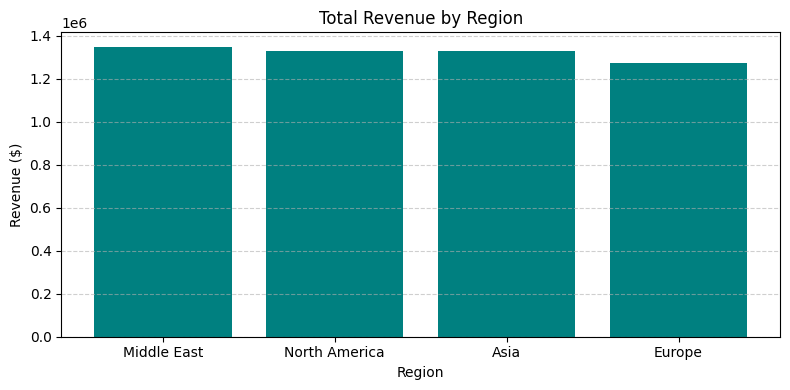

In [ ]:
region_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
plt.bar(region_rev.index, region_rev.values, color='teal')  # Bar Chart: Total Revenue by Region
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

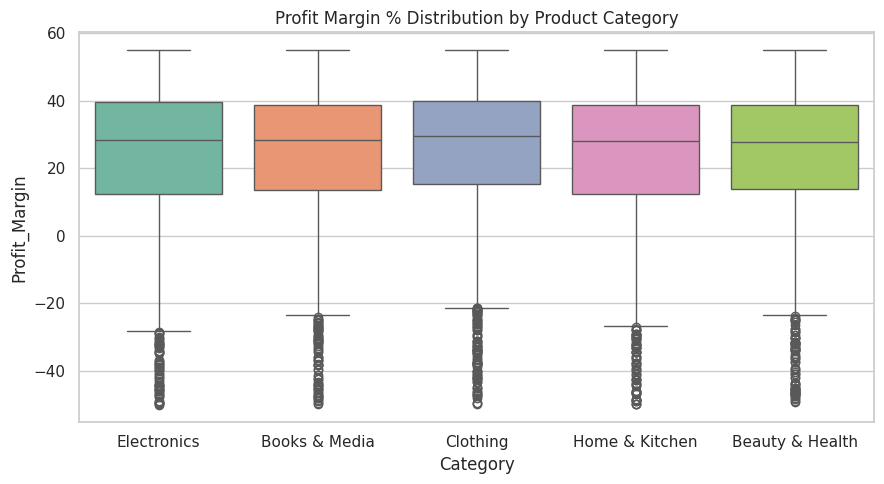

In [ ]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Category', y='Profit_Margin', palette='Set2') # Boxplot: Profit Margin Distribution across Categories
plt.title('Profit Margin % Distribution by Product Category')
plt.tight_layout()
plt.show()

### Problems and Solutions
1. Identifying Unprofitable Discount Strategies

Question: How many orders with a discount greater than 20% resulted in a negative profit, and what is the total loss incurred from these transactions?

In [ ]:
# Filter orders with >20% discount and negative profit
loss_orders = df[(df['Discount'] > 0.20) & (df['Profit'] < 0)]

print("Number of Unprofitable Discounted Orders:", len(loss_orders))
print("Total Financial Loss: $", abs(loss_orders['Profit'].sum()))

Number of Unprofitable Discounted Orders: 1338
Total Financial Loss: $ 83495.35


2. High Shipping Cost Ratios on Low-Value Items

Question: Which product category has the highest average ratio of shipping cost relative to order revenue?

In [ ]:
# Calculate shipping cost as a percentage of total revenue per order
df['Shipping_To_Revenue_Ratio'] = df['Shipping_Cost'] / df['Revenue']

# Group by Category and find the mean ratio
shipping_impact = df.groupby('Category')['Shipping_To_Revenue_Ratio'].mean().sort_values(ascending=False)
print(shipping_impact)

Category
Books & Media      0.660194
Beauty & Health    0.647678
Clothing           0.351941
Home & Kitchen     0.230686
Electronics        0.067105
Name: Shipping_To_Revenue_Ratio, dtype: float64


3. Revenue Lost to Cancellations & Returns

Question: What is the total dollar amount tied up in Cancelled and Returned orders, and what percentage of total gross revenue does this represent?

In [ ]:
# Group revenue by Order Status
status_rev = df.groupby('Order_Status')['Revenue'].sum()
total_rev = df['Revenue'].sum()

lost_rev = status_rev.get('Cancelled', 0) + status_rev.get('Returned', 0)
lost_pct = (lost_rev / total_rev) * 100

print(f"Revenue Lost (Cancelled + Returned): ${lost_rev:,.2f}")
print(f"Percentage of Gross Revenue: {lost_pct:.2f}%")

Revenue Lost (Cancelled + Returned): $1,438,776.62
Percentage of Gross Revenue: 27.23%


4. Identifying Regional Top-Performing Products

Question: What are the top 3 revenue-generating products in each geographical region?

In [ ]:
# Group by Region and Product_Name to calculate total revenue
top_products = df.groupby(['Region', 'Product_Name'])['Revenue'].sum().reset_index()

# Sort and get top 3 per region
top_3_regional = top_products.sort_values(['Region', 'Revenue'], ascending=[True, False]).groupby('Region').head(3)
print(top_3_regional)

            Region        Product_Name    Revenue
32            Asia      MacBook Air M2  128986.28
20            Asia         Dell XPS 15   79973.83
0             Asia        ASUS ZenBook   70195.15
90          Europe         Dell XPS 15  104492.71
101         Europe  Lenovo ThinkPad X1   94582.39
102         Europe      MacBook Air M2   86088.49
171    Middle East  Lenovo ThinkPad X1  124400.43
163    Middle East     HP Spectre x360  104004.49
172    Middle East      MacBook Air M2   85189.14
241  North America  Lenovo ThinkPad X1  106230.72
233  North America     HP Spectre x360   89724.61
230  North America         Dell XPS 15   84238.64


5. Average Order Value (AOV) by Payment Method

Question: Which payment method yields the highest Average Order Value (AOV)?

In [ ]:
# Calculate mean revenue per payment method
aov_by_payment = df.groupby('Payment_Method')['Revenue'].mean().sort_values(ascending=False)
print(aov_by_payment)

Payment_Method
PayPal              565.728347
Credit Card         544.020636
Google Pay          542.669508
Debit Card          532.566797
Cash on Delivery    511.307723
Bank Transfer       507.411950
Apple Pay           492.003447
Name: Revenue, dtype: float64


6. Impact of Delivery Delays on Customer Segments

Question: How many orders took longer than 7 shipping days, broken down by Customer_Segment?

In [ ]:
# Filter orders with Shipping_Days > 7
delayed_orders = df[df['Shipping_Days'] > 7]

# Count by Customer Segment
delayed_by_segment = delayed_orders.groupby('Customer_Segment')['Order_ID'].count()
print(delayed_by_segment)

Customer_Segment
New        1418
Premium    1449
Regular    3777
VIP         769
Name: Order_ID, dtype: int64


7. Monthly Revenue Growth Rate (MoM)

Question: What is the percentage growth in revenue from month to month?

In [ ]:
# Create Year-Month period column
df['YearMonth'] = df['Order_Date'].dt.to_period('M')

# Aggregate monthly revenue and compute percentage change
monthly_rev = df.groupby('YearMonth')['Revenue'].sum()
mom_growth = monthly_rev.pct_change() * 100

print(mom_growth.dropna())

YearMonth
2021-02    -10.298035
2021-03    -11.336788
2021-04    275.418655
2021-05     11.529158
2021-06     -0.223043
2021-07      6.382908
2021-08    137.111726
2021-09    -44.821388
2021-10     77.956462
2021-11     18.167530
2021-12    -20.541431
2022-01     38.734943
2022-02    -18.965636
2022-03      0.819985
2022-04     11.810383
2022-05     14.917387
2022-06    -18.751121
2022-07     13.898654
2022-08     39.903213
2022-09    -16.509572
2022-10     28.081170
2022-11    -18.352917
2022-12     46.904037
2023-01     -7.420466
2023-02    -14.415335
2023-03     43.645310
2023-04      7.497841
2023-05    -20.870210
2023-06     10.689103
2023-07      4.886578
2023-08      7.075074
2023-09      8.375038
2023-10      7.909850
2023-11    -12.076129
2023-12    -25.584479
2024-01     35.744315
2024-02    -39.961969
2024-03     54.113493
2024-04    -42.239942
2024-05     25.756452
2024-06    -32.787784
2024-07    -10.905927
2024-08    -32.894353
2024-09    -28.819060
2024-10    -12.629995


8. Anomaly Detection in Shipping Days

Question: Using NumPy, what are the 95th and 99th percentiles for Shipping_Days, and which orders exceed these benchmarks?

In [ ]:
# Calculate percentiles
p95 = np.percentile(df['Shipping_Days'], 95)
p99 = np.percentile(df['Shipping_Days'], 99)

# Filter outliers
extreme_delays = df[df['Shipping_Days'] > p99]

print("95th Percentile: {p95} days | 99th Percentile: {p99} days")
print("Number of extreme delay orders:", len(extreme_delays))

95th Percentile: {p95} days | 99th Percentile: {p99} days
Number of extreme delay orders: 0


9. High Revenue vs. Low Margin Categories

Question: Which product category generates the most total revenue, and what is its corresponding average profit margin percentage?

In [ ]:
# Aggregate total revenue and average profit margin by category
category_perf = df.groupby('Category').agg({
    'Revenue': 'sum',
    'Profit_Margin': 'mean'
}).sort_values('Revenue', ascending=False)

print(category_perf)

                    Revenue  Profit_Margin
Category                                  
Electronics      3382028.46      23.344370
Home & Kitchen    892842.02      23.019188
Clothing          407471.79      24.803338
Books & Media     386644.46      23.611307
Beauty & Health   215400.97      23.477439


10. Seasonal Sales Demand & Unit Volume

Question: Which season records the highest total units sold (Quantity), and what is the total profit for that season?

In [ ]:
# Group by Season to calculate total units sold and net profit
seasonal_performance = df.groupby('Season').agg({
    'Quantity': 'sum',
    'Profit': 'sum'
}).sort_values('Quantity', ascending=False)

print(seasonal_performance)

        Quantity     Profit
Season                     
Spring      7089  355966.90
Summer      6870  366725.69
Fall        6854  368748.60
Winter      6500  346197.12
